## 내부 모듈 구현하기

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')
mpl.font_manager.findfont(font)

print("슝=3")

슝=3


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import io
import time
import random
import math

import seaborn # Attention 시각화를 위해 필요!

print(torch.__version__)

2.7.1+cu118


In [3]:

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

print("슝=3")

슝=3


In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)  # Linear Layer
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1)
        QK = torch.matmul(Q, K.transpose(-2, -1))

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk += (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

print("슝=3")

슝=3


In [5]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.w_1(x))
        out = self.w_2(out)

        return out

print("슝=3")

슝=3


In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

print("슝=3")

슝=3


In [7]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


In [8]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

print("슝=3")

슝=3


In [9]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, causality_mask, padding_mask)

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [10]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [11]:
import torch
import numpy as np

def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask.unsqueeze(1).unsqueeze(2)

def generate_causality_mask(size):
    """Causal Mask 생성 (Upper triangular matrix)"""
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(tgt)
    seq_len = tgt.shape[-1]
    causal_mask = generate_causality_mask(seq_len)
    batch_size = src.shape[0]
    dec_mask = causal_mask.expand(batch_size, 1, seq_len, seq_len)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

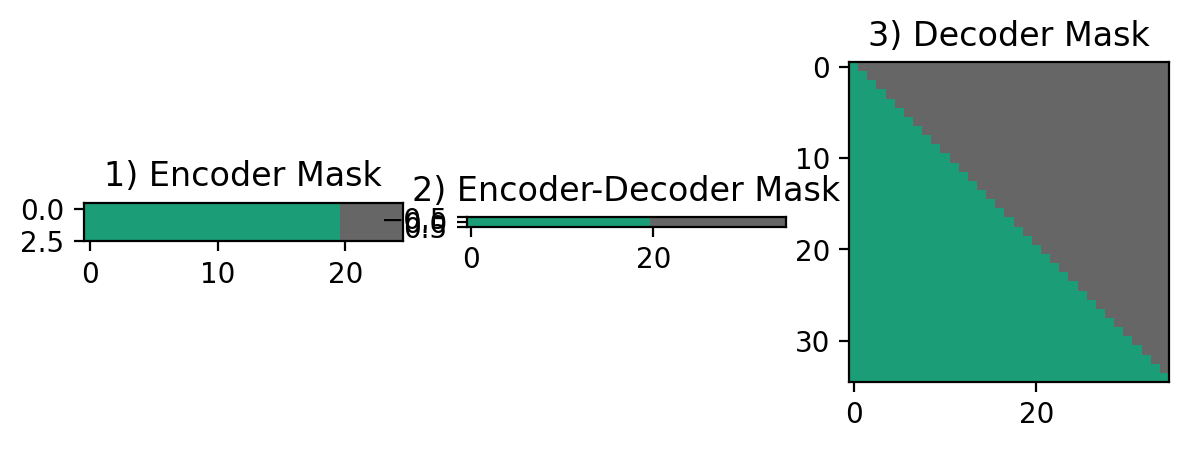

In [12]:
import matplotlib.pyplot as plt

batch, length = 16, 20
src_padding = 5
tgt_padding = 15

src_pad = torch.zeros((batch, src_padding))
tgt_pad = torch.zeros((batch, tgt_padding))

sample_data = torch.ones((batch, length))
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')

ax1.imshow(enc_mask[:3, 0, 0].numpy(), cmap='Dark2')
ax2.imshow(dec_enc_mask[0, 0].numpy(), cmap='Dark2')
ax3.imshow(dec_mask[0, 0].numpy(), cmap='Dark2')

plt.show()

In [13]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = torch.tensor(step, dtype=torch.float32)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * torch.minimum(arg1, arg2)

model = nn.Linear(10, 10)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9)

print("슝=3")

슝=3


## 프로젝트: 더 멋진 번역기 만들기

In [14]:
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = data_dir+"/korean-english-park.train.ko"
eng_path = data_dir+"/korean-english-park.train.en"

# 데이터 정제 및 토큰화
def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)

    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))

    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)

In [15]:
def preprocess_sentence(sentence):

  sentence = sentence.lower()
  sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  return sentence

In [16]:
# Sentencepiece를 활용하여 학습한 tokenizer를 생성합니다.
def generate_tokenizer(corpus,
                        vocab_size,
                        lang="ko",
                        pad_id=0,
                        bos_id=1,
                        eos_id=2,
                        unk_id=3):
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
      for row in corpus: f.write(str(row) + '\n')

    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
      '--input=./%s --model_prefix=%s --vocab_size=%d'\
      % (file, model, vocab_size) + \
      '--pad_id==%d --bos_id=%d --eos_id=%d --unk_id=%d'\
      % (pad_id, bos_id, eos_id, unk_id)
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

eng_corpus = []
kor_corpus = []

for pair in cleaned_corpus:
    k, e = pair.split("\t")

    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000--pad_id==0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

True

In [17]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm  # 진행 과정 보기

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus)

# 토큰의 길이가 50 이하인 문장만 남깁니다.
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 패딩처리를 완료하여 학습용 데이터를 완성합니다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print(enc_train.shape, dec_train.shape)

  0%|          | 0/78968 [00:00<?, ?it/s]

torch.Size([72107, 50]) torch.Size([72107, 50])


In [18]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):

        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

In [19]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.shape[-1]
        QK = torch.matmul(Q, K.transpose(-2, -1))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk = scaled_qk.masked_fill(mask == 0, float('-1e9'))

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

In [20]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)

        return out

In [21]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

In [22]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

In [23]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

In [24]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []

        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, causality_mask, padding_mask
            )

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

In [25]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):

        super(Transformer, self).__init__()

        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.shape[1]

        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))

        pos_enc = self.pos_encoding[:seq_len, :].unsqueeze(0).to(x.device)
        out += pos_enc

        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns


In [26]:
def generate_padding_mask(seq):
    """ 패딩된 부분(0)을 1로 변환하여 마스크 생성 """
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(src_len, tgt_len):
    """ 미래 정보를 참조하지 않도록 Causal Mask 생성 """
    mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
    return mask.float()

def generate_masks(src, tgt):
    """ Encoder-Decoder에서 사용할 마스크 생성 """
    enc_mask = generate_padding_mask(src)
    dec_mask = generate_padding_mask(tgt)

    dec_causality_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1])
    dec_mask = torch.max(dec_mask, dec_causality_mask.to(dec_mask.device))

    dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])
    dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask.to(enc_mask.device))

    return enc_mask, dec_enc_mask, dec_mask

In [27]:
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
)

In [28]:
import math

class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]

In [29]:
learning_rate = LearningRateScheduler(optimizer, d_model=512)

optimizer = torch.optim.Adam(optimizer.param_groups,
                             lr=learning_rate.get_lr()[0],
                             betas=(0.9, 0.98),
                             eps=1e-9)

In [30]:
loss_object = torch.nn.CrossEntropyLoss(reduction='none')

def loss_function(real, pred):
    mask = (real != 0)
    loss_ = loss_object(pred, real)

    # Masking 되지 않은 입력의 개수로 Scaling하는 과정
    mask = mask.float()
    loss_ *= mask

    return loss_.sum() / mask.sum()

In [31]:
# Train Step 함수 정의
def train_step(src, tgt, model, optimizer):
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)

    # 계산된 loss에 대해 역전파(Backpropagation)를 적용해 학습을 진행합니다.
    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions[:, :-1])

    loss.backward()

    # 최종적으로 optimizer.step()이 사용됩니다.
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns


In [32]:
# Attention 시각화 함수

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    def draw(data, ax, x="auto", y="auto"):
        import seaborn
        seaborn.heatmap(data,
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer+1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer+1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

In [33]:
# 번역 생성 함수

def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    sentence = preprocess_sentence(sentence)

    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)

    _input = torch.tensor(tokens).unsqueeze(0)

    ids = []
    output = torch.tensor([tgt_tokenizer.bos_id()]).unsqueeze(0)
    for i in range(dec_train.shape[-1]):
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(_input, output)

        predictions, enc_attns, dec_attns, dec_enc_attns = \
        model(_input, output, enc_padding_mask, combined_mask, dec_padding_mask)

        predicted_id = torch.argmax(torch.softmax(predictions, dim=-1)[0, -1]).item()

        if tgt_tokenizer.eos_id() == predicted_id:
            result = tgt_tokenizer.decode_ids(ids)
            return pieces, result, enc_attns, dec_attns, dec_enc_attns

        ids.append(predicted_id)
        output = torch.cat([output, torch.tensor([[predicted_id]])], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)

    return pieces, result, enc_attns, dec_attns, dec_enc_attns

In [34]:
# 번역 생성 및 Attention 시각화 결합

def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = \
    evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)

In [35]:
# # 학습 코드 첨부

# # from tqdm import tqdm

# BATCH_SIZE = 64
# EPOCHS = 20

# examples = [
#             "오바마는 대통령이다.",
#             "시민들은 도시 속에 산다.",
#             "커피는 필요 없다.",
#             "일곱 명의 사망자가 발생했다."
# ]

# for epoch in range(EPOCHS):
#     total_loss = 0

#     idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
#     random.shuffle(idx_list)
#     t = tqdm(idx_list)

#     for (batch, idx) in enumerate(t):
#         batch_loss, enc_attns, dec_attns, dec_enc_attns = \
#         train_step(enc_train[idx:idx+BATCH_SIZE],
#                     dec_train[idx:idx+BATCH_SIZE],
#                     transformer,
#                     optimizer)

#         total_loss += batch_loss

#         t.set_description('Epoch %2d' % (epoch + 1))
#         t.set_postfix({'Loss': '%.4f' % (total_loss.item() / (batch + 1))})

#     for example in examples:
#         translate(example, transformer, ko_tokenizer, en_tokenizer)

## 번역가는 대화에도 능하다 [프로젝트]

In [1]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.7.1+cu118


In [2]:
import urllib.request
import zipfile

zip_filename = "spa-eng.zip"
zip_url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"

urllib.request.urlretrieve(zip_url, zip_filename)

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(os.path.dirname(zip_filename))

print("슝=3")

슝=3


In [3]:
extracted_folder = "./spa-eng"
file_path = os.path.join(extracted_folder, "spa.txt")

with open(file_path, "r") as f:
    spa_eng_sentences = f.read().splitlines()

spa_eng_sentences = list(set(spa_eng_sentences))
total_sentence_count = len(spa_eng_sentences)
print("Example:", total_sentence_count)

for sen in spa_eng_sentences[0:100][::20]:
    print(">>", sen)

Example: 118964
>> Where have you been living?	¿Dónde has estado viviendo?
>> Tom has convinced me.	Tom me convenció.
>> She forced him to do it.	Ella le obligó a hacerlo.
>> I've rented a room in Boston for a month.	He alquilado una habitación en Boston durante un mes.
>> Whether rains or not, the game is going to be held.	Se va a celebrar el partido tanto si llueve como si no.


In [4]:
# Q. 전처리 함수를 만들어 보세요. 아래 기능을 추가해주세요.
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    return sentence

In [5]:
spa_eng_sentences = list(map(preprocess_sentence, spa_eng_sentences))

print('슝=3')

슝=3


In [6]:
test_sentence_count = total_sentence_count // 200
print("Test Size: ", test_sentence_count)
print("\n")

train_spa_eng_sentences = spa_eng_sentences[:-test_sentence_count]
test_spa_eng_sentences = spa_eng_sentences[-test_sentence_count:]
print("Train Example:", len(train_spa_eng_sentences))
for sen in train_spa_eng_sentences[0:100][::20]:
    print(">>", sen)
print("\n")
print("Test Example:", len(test_spa_eng_sentences))
for sen in test_spa_eng_sentences[0:100][::20]:
    print(">>", sen)

Test Size:  594


Train Example: 118370
>> where have you been living?	¿dónde has estado viviendo?
>> tom has convinced me.	tom me convenció.
>> she forced him to do it.	ella le obligó a hacerlo.
>> i've rented a room in boston for a month.	he alquilado una habitación en boston durante un mes.
>> whether rains or not, the game is going to be held.	se va a celebrar el partido tanto si llueve como si no.


Test Example: 594
>> she'd never been this frightened before.	ella nunca había estado tan asustada.
>> you can't be hungry. you've just had dinner.	no puedes tener hambre. acabas de cenar.
>> tom felt a pain in his side.	tom sintió un dolor en su costado.
>> i should go with you.	debería ir con vosotras.
>> this is a bit too tight around my neck.	esto está un poco muy apretado alrededor de mi cuello.


In [7]:
def split_spa_eng_sentences(spa_eng_sentences):
    spa_sentences = []
    eng_sentences = []
    for spa_eng_sentence in tqdm(spa_eng_sentences):
        eng_sentence, spa_sentence = spa_eng_sentence.split('\t')
        spa_sentences.append(spa_sentence)
        eng_sentences.append(eng_sentence)
    return eng_sentences, spa_sentences

print('슝=3')

슝=3


In [8]:
train_eng_sentences, train_spa_sentences = split_spa_eng_sentences(train_spa_eng_sentences)
print(len(train_eng_sentences))
print(train_eng_sentences[0])
print('\n')
print(len(train_spa_sentences))
print(train_spa_sentences[0])

  0%|          | 0/118370 [00:00<?, ?it/s]

118370
where have you been living?


118370
¿dónde has estado viviendo?


In [9]:
test_eng_sentences, test_spa_sentences = split_spa_eng_sentences(test_spa_eng_sentences)
print(len(test_eng_sentences))
print(test_eng_sentences[0])
print('\n')
print(len(test_spa_sentences))
print(test_spa_sentences[0])

  0%|          | 0/594 [00:00<?, ?it/s]

594
she'd never been this frightened before.


594
ella nunca había estado tan asustada.


In [10]:
def generate_tokenizer(corpus,
                       vocab_size,
                       lang="spa-eng",
                       pad_id=0,   # pad token의 일련번호
                       bos_id=1,  # 문장의 시작을 의미하는 bos token(<s>)의 일련번호
                       eos_id=2,  # 문장의 끝을 의미하는 eos token(</s>)의 일련번호
                       unk_id=3):   # unk token의 일련번호
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
        for row in corpus: f.write(str(row) + '\n')

    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
        '--input=./%s --model_prefix=%s --vocab_size=%d'\
        % (file, model, vocab_size) + \
        '--pad_id==%d --bos_id=%d --eos_id=%d --unk_id=%d'\
        % (pad_id, bos_id, eos_id, unk_id)
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer

print("슝=3")

슝=3


In [11]:
VOCAB_SIZE = 20000
tokenizer = generate_tokenizer(train_eng_sentences + train_spa_sentences, VOCAB_SIZE, 'spa-eng')
tokenizer.set_encode_extra_options("bos:eos")  # 문장 양 끝에 <s> , </s> 추가

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././spa-eng_corpus.txt --model_prefix=spa-eng_spm --vocab_size=20000--pad_id==0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././spa-eng_corpus.txt
  input_format: 
  model_prefix: spa-eng_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_al

True

In [12]:
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        tokens = tokenizer.encode_as_ids(sentence)
        corpus.append(tokens)
    return corpus

print('슝=3')

슝=3


In [13]:
eng_corpus = make_corpus(train_eng_sentences, tokenizer)
spa_corpus = make_corpus(train_spa_sentences, tokenizer)

  0%|          | 0/118370 [00:00<?, ?it/s]

  0%|          | 0/118370 [00:00<?, ?it/s]

In [14]:
print(train_eng_sentences[0])
print(eng_corpus[0])
print('\n')
print(train_spa_sentences[0])
print(spa_corpus[0])

where have you been living?
[1, 163, 39, 12, 160, 1070, 8, 2]


¿dónde has estado viviendo?
[1, 18, 313, 68, 346, 2770, 8, 2]


In [15]:
MAX_LEN = 50

def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) > max_len:
            seq = seq[:max_len]
        # 부족한 길이는 pad_value로 채우기
        else:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

enc_ndarray = pad_sequences_custom(eng_corpus, max_len=MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences_custom(spa_corpus, max_len=MAX_LEN, pad_value=0)

print(enc_ndarray.shape)  # 예) [batch_size, 50]
print(dec_ndarray.shape)  # 예) [batch_size, 50]
print("슝=3")

torch.Size([118370, 50])
torch.Size([118370, 50])
슝=3


In [16]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dataset = TensorDataset(enc_ndarray, dec_ndarray)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

print("슝=3")

슝=3


In [17]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
print("슝=3")

슝=3


In [18]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

슝=3


In [20]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")

슝=3


In [21]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

print("슝=3")

슝=3


In [22]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


In [23]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)
print("슝=3")

슝=3


In [24]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [25]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [26]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(device)

d_model = 512

print("슝=3")

슝=3


In [27]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=60): # 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

슝=3


In [28]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


In [29]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


In [30]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [31]:
%%time

EPOCHS = 3

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)  # train_loader는 PyTorch DataLoader입니다.
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        # train_step 함수는 (loss, enc_attns, dec_attns, dec_enc_attns)를 반환합니다.
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()  # PyTorch에서는 loss.numpy() 대신 loss.item() 사용
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    print(f"Epoch {epoch+1}, Loss: {total_loss / dataset_count:.4f}")

  0%|          | 0/1850 [00:00<?, ?it/s]

Epoch 1, Loss: 3982.1839


  0%|          | 0/1850 [00:00<?, ?it/s]

Epoch 2, Loss: 2652.4310


  0%|          | 0/1850 [00:00<?, ?it/s]

Epoch 3, Loss: 2141.3176
CPU times: user 15min 3s, sys: 3.18 s, total: 15min 6s
Wall time: 13min 45s


In [32]:
# 아래 두 문장을 바꿔가며 테스트 해보세요
reference = "많 은 자연어 처리 연구자 들 이 트랜스포머 를 선호 한다".split()
candidate = "적 은 자연어 학 개발자 들 가 트랜스포머 을 선호 한다 요".split()

print("원문:", reference)
print("번역문:", candidate)
print("BLEU Score:", sentence_bleu([reference], candidate))

원문: ['많', '은', '자연어', '처리', '연구자', '들', '이', '트랜스포머', '를', '선호', '한다']
번역문: ['적', '은', '자연어', '학', '개발자', '들', '가', '트랜스포머', '을', '선호', '한다', '요']
BLEU Score: 8.190757052088229e-155


/opt/conda/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/opt/conda/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


In [33]:
print("1-gram:", sentence_bleu([reference], candidate, weights=[1, 0, 0, 0]))
print("2-gram:", sentence_bleu([reference], candidate, weights=[0, 1, 0, 0]))
print("3-gram:", sentence_bleu([reference], candidate, weights=[0, 0, 1, 0]))
print("4-gram:", sentence_bleu([reference], candidate, weights=[0, 0, 0, 1]))

1-gram: 0.5
2-gram: 0.18181818181818182
3-gram: 2.2250738585072626e-308
4-gram: 2.2250738585072626e-308


In [34]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)  # smoothing_function 적용

print("BLEU-1:", calculate_bleu(reference, candidate, weights=[1, 0, 0, 0]))
print("BLEU-2:", calculate_bleu(reference, candidate, weights=[0, 1, 0, 0]))
print("BLEU-3:", calculate_bleu(reference, candidate, weights=[0, 0, 1, 0]))
print("BLEU-4:", calculate_bleu(reference, candidate, weights=[0, 0, 0, 1]))

print("\nBLEU-Total:", calculate_bleu(reference, candidate))

BLEU-1: 0.5
BLEU-2: 0.18181818181818182
BLEU-3: 0.010000000000000004
BLEU-4: 0.011111111111111112

BLEU-Total: 0.05637560315259291


In [35]:
import torch
import torch.nn.functional as F

def translate(tokens, model, src_tokenizer, tgt_tokenizer):
    # tokens: 입력 토큰 리스트
    # MAX_LEN: 최대 길이 (전역 변수 혹은 상수)
    # device: 모델과 데이터가 위치한 디바이스

    # tokens 길이가 MAX_LEN보다 크면 자르고, 작으면 0으로 패딩
    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN]
    else:
        tokens = tokens + [0] * (MAX_LEN - len(tokens))

    # 배치 차원을 추가하여 텐서로 변환 (shape: [1, MAX_LEN])
    padded_tokens = torch.tensor([tokens], dtype=torch.long, device=device)

    ids = []
    # 디코더의 첫 입력은 BOS 토큰 (배치 차원 추가)
    output = torch.tensor([[tgt_tokenizer.bos_id()]], dtype=torch.long, device=device)

    for i in range(MAX_LEN):
        # generate_masks는 padded_tokens와 현재 output으로부터 마스크들을 생성합니다.
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(padded_tokens, output)

        # 모델 예측: predictions shape: [batch, seq_len, num_classes]
        predictions, _, _, _ = model(padded_tokens, output, enc_padding_mask, combined_mask, dec_padding_mask)

        # 마지막 시퀀스 위치의 예측값을 소프트맥스 후 argmax로 선택
        predicted_id = predictions[0, -1].softmax(dim=-1).argmax(dim=-1).item()

        # EOS 토큰에 도달하면 현재까지의 예측 토큰 ids를 디코딩 후 반환
        if tgt_tokenizer.eos_id() == predicted_id:
            result = tgt_tokenizer.decode_ids(ids)
            return result

        ids.append(predicted_id)
        # 현재 output에 새로운 예측 토큰을 연결 (dim=1)
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)

    result = tgt_tokenizer.decode_ids(ids)
    return result

print("슝=3")

슝=3


In [36]:
def eval_bleu_single(model, src_sentence, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    src_tokens = src_tokenizer.encode_as_ids(src_sentence)
    tgt_tokens = tgt_tokenizer.encode_as_ids(tgt_sentence)

    if (len(src_tokens) > MAX_LEN): return None
    if (len(tgt_tokens) > MAX_LEN): return None

    reference = tgt_sentence.split()
    candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer).split()

    score = sentence_bleu([reference], candidate,
                          smoothing_function=SmoothingFunction().method1)

    if verbose:
        print("Source Sentence: ", src_sentence)
        print("Model Prediction: ", candidate)
        print("Real: ", reference)
        print("Score: %lf\n" % score)

    return score

print('슝=3')

슝=3


In [37]:
# Q. 인덱스를 바꿔가며 테스트해 보세요
test_idx = 0

eval_bleu_single(transformer,
                 test_eng_sentences[test_idx],
                 test_spa_sentences[test_idx],
                 tokenizer,
                 tokenizer)

Source Sentence:  she'd never been this frightened before.
Model Prediction:  ['ellautautautautautautautauta', 'la', 'sueldo', 'sueldo', 'sueldo', 'de', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar', 'obligar']
Real:  ['ella', 'nunca', 'había', 'estado', 'tan', 'asustada.']
Score: 0.000000



0

In [38]:
def eval_bleu(model, src_sentences, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    total_score = 0.0
    sample_size = len(src_sentences)

    for idx in tqdm(range(sample_size)):
        score = eval_bleu_single(model, src_sentences[idx], tgt_sentence[idx], src_tokenizer, tgt_tokenizer, verbose)
        if not score: continue

        total_score += score

    print("Num of Sample:", sample_size)
    print("Total Score:", total_score / sample_size)

print("슝=3")

슝=3


In [39]:
eval_bleu(transformer, test_eng_sentences, test_spa_sentences, tokenizer, tokenizer, verbose=False)

  0%|          | 0/594 [00:00<?, ?it/s]

Num of Sample: 594
Total Score: 0.004272568772184284


In [40]:
def beam_search_decoder(prob, beam_size):
    sequences = [[[], 1.0]]  # 생성된 문장과 점수를 저장

    for tok in prob:
        all_candidates = []

        for seq, score in sequences:
            for idx, p in enumerate(tok): # 각 단어의 확률을 총점에 누적 곱
                candidate = [seq + [idx], score * -math.log(-(p-1))]
                all_candidates.append(candidate)

        ordered = sorted(all_candidates,
                         key=lambda tup:tup[1],
                         reverse=True) # 총점 순 정렬
        sequences = ordered[:beam_size] # Beam Size에 해당하는 문장만 저장

    return sequences

print("슝=3")

슝=3


In [41]:
vocab = {
    0: "<pad>",
    1: "까요?",
    2: "커피",
    3: "마셔",
    4: "가져",
    5: "될",
    6: "를",
    7: "한",
    8: "잔",
    9: "도",
}

prob_seq = [[0.01, 0.01, 0.60, 0.32, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.75, 0.01, 0.01, 0.17],
            [0.01, 0.01, 0.01, 0.35, 0.48, 0.10, 0.01, 0.01, 0.01, 0.01],
            [0.24, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.68],
            [0.01, 0.01, 0.12, 0.01, 0.01, 0.80, 0.01, 0.01, 0.01, 0.01],
            [0.01, 0.81, 0.01, 0.01, 0.01, 0.01, 0.11, 0.01, 0.01, 0.01],
            [0.70, 0.22, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]]

prob_seq = np.array(prob_seq)
beam_size = 3

result = beam_search_decoder(prob_seq, beam_size)

for seq, score in result:
    sentence = ""

    for word in seq:
        sentence += vocab[word] + " "

    print(sentence, "// Score: %.4f" % score)

커피 를 가져 도 될 까요? <pad> <pad> <pad> <pad>  // Score: 42.5243
커피 를 마셔 도 될 까요? <pad> <pad> <pad> <pad>  // Score: 28.0135
마셔 를 가져 도 될 까요? <pad> <pad> <pad> <pad>  // Score: 17.8983


In [42]:
import torch
import torch.nn.functional as F

def calc_prob(src_ids, tgt_ids, model):
    # 마스크 생성 (PyTorch 버전)
    enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src_ids, tgt_ids)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src_ids,
        tgt_ids,
        enc_padding_mask,
        combined_mask,
        dec_padding_mask
    )

    # 마지막 차원에 대해 softmax 적용하여 확률값 계산
    return F.softmax(predictions, dim=-1)

print("슝=3")

슝=3


In [43]:
import numpy as np
import torch

def beam_search_decoder(sentence,
                        src_len,
                        tgt_len,
                        model,
                        src_tokenizer,
                        tgt_tokenizer,
                        beam_size):
    # 입력 문장을 토큰화
    tokens = src_tokenizer.encode_as_ids(sentence)

    # src_in: [1, src_len] 크기의 텐서로 padding (0: 패딩 토큰)
    padded = np.zeros((1, src_len), dtype=np.int64)
    padded[0, :len(tokens)] = tokens
    src_in = torch.tensor(padded, dtype=torch.long, device=device)

    # beam search용 캐시 배열들
    pred_cache = np.zeros((beam_size * beam_size, tgt_len), dtype=np.int64)
    pred_tmp = np.zeros((beam_size, tgt_len), dtype=np.int64)

    eos_flag = np.zeros((beam_size,), dtype=np.int64)  # EOS를 만난 branch 표시 (EOS: -1)
    scores = np.ones((beam_size,), dtype=np.float32)     # 각 branch의 score (확률 곱)

    # 디코더 첫 입력은 BOS 토큰
    pred_tmp[:, 0] = tgt_tokenizer.bos_id()

    # 초기 디코더 입력 (branch 0의 첫 토큰) -> shape: [1, 1]
    dec_in = torch.tensor(pred_tmp[0, :1], dtype=torch.long, device=device).unsqueeze(0)
    # calc_prob()는 softmax를 적용한 확률 텐서를 반환함
    prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

    # seq_pos: 디코더 시퀀스 위치
    for seq_pos in range(1, tgt_len):
        score_cache = np.ones((beam_size * beam_size,), dtype=np.float32)

        # 각 beam branch에 대해 캐시 초기화
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            score_cache[cache_pos:cache_pos+beam_size] = scores[branch_idx]
            pred_cache[cache_pos:cache_pos+beam_size, :seq_pos] = pred_tmp[branch_idx, :seq_pos]

        # 각 beam branch에 대해 후보 확률 계산 및 캐시 업데이트
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            if seq_pos != 1:
                # 해당 branch의 현재까지의 시퀀스를 디코더 입력으로 변환
                dec_in_np = pred_cache[branch_idx, :seq_pos]
                dec_in = torch.tensor(dec_in_np, dtype=torch.long, device=device).unsqueeze(0)
                prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

            # 각 branch 내에서 beam_size만큼의 후보 토큰을 선택
            for beam_idx in range(beam_size):
                max_idx = np.argmax(prob)
                # 후보 branch의 score 업데이트 (곱셈으로 누적)
                score_cache[cache_pos + beam_idx] *= prob[max_idx]
                pred_cache[cache_pos + beam_idx, seq_pos] = max_idx
                # 이미 선택된 토큰은 다시 선택되지 않도록 -1로 마킹
                prob[max_idx] = -1

        # 각 beam branch에서 최고 score를 가진 후보를 선택
        for beam_idx in range(beam_size):
            if eos_flag[beam_idx] == -1:
                continue
            max_idx = np.argmax(score_cache)
            prediction = pred_cache[max_idx, :seq_pos+1].copy()
            pred_tmp[beam_idx, :seq_pos+1] = prediction
            scores[beam_idx] = score_cache[max_idx]
            score_cache[max_idx] = -1  # 해당 후보 제거

            # 만약 EOS 토큰이면 해당 branch는 종료 표시 (-1)
            if prediction[-1] == tgt_tokenizer.eos_id():
                eos_flag[beam_idx] = -1

    # 각 branch의 예측 시퀀스에서 EOS 토큰 이전까지만 추출하여 결과 반환
    pred = []
    for long_pred in pred_tmp:
        eos_token = tgt_tokenizer.eos_id()
        # EOS 토큰이 없는 경우, 전체 시퀀스를 사용하도록 처리할 수 있음
        try:
            eos_idx = list(long_pred).index(eos_token)
        except ValueError:
            eos_idx = tgt_len - 1
        short_pred = long_pred[:eos_idx+1]
        pred.append(short_pred.tolist())

    return pred

print("슝=3")

슝=3


In [44]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                            candidate,
                            weights=weights,
                            smoothing_function=SmoothingFunction().method1)

print('슝=3')

슝=3


In [45]:
def beam_bleu(reference, ids, tokenizer):
    # 기준 문장을 토큰화
    reference_tokens = reference.split()

    total_score = 0.0
    num_candidates = len(ids)
    if num_candidates == 0:
        return 0.0

    for candidate_ids in ids:
        # 후보 문장을 디코딩 후 토큰화
        candidate_sentence = tokenizer.decode_ids(candidate_ids)
        candidate_tokens = candidate_sentence.split()

        score = calculate_bleu(reference_tokens, candidate_tokens)

        print(f"Reference: {reference_tokens}")
        print(f"Candidate: {candidate_tokens}")
        print(f"BLEU: {score}")

        total_score += score

    return total_score / num_candidates

print("슝=3")

슝=3


In [46]:
# Q. 인덱스를 바꿔가며 확인해 보세요
test_idx = 1

ids = \
beam_search_decoder(test_eng_sentences[test_idx],
                    MAX_LEN,
                    MAX_LEN,
                    transformer,
                    tokenizer,
                    tokenizer,
                    beam_size=5)

bleu = beam_bleu(test_spa_sentences[test_idx], ids, tokenizer)
print(bleu)

Reference: ['muchas', 'gracias', 'por', 'la', 'atención', 'desmerecida.']
Candidate: ['movida', 'movida', 'movida', 'un', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'a', 'políticas', 'políticas', 'políticas', 'políticas', 'políticas', 'políticas', 'el', 'blink', 'blink', 'blink', 'enanaanaanaanaanaanaanaanaanaanaanaanaanaanaana']
BLEU: 0
Reference: ['muchas', 'gracias', 'por', 'la', 'atención', 'desmerecida.']
Candidate: ['movida', 'movida', 'movida', 'un', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'enemiga', 'a', 'políticas', 'políticas', 'políticas', 'políticas', 'políticas', 'políticas', 'el', 'perú', 'el', 'de', 'blink', 'pepperonianaanaanaanaanaanaanaanaanaanaanaanaanaana']
BLEU: 0
Refe

In [48]:
import gensim.downloader as api
from contextlib import redirect_stdout, redirect_stderr
import os, sys

with open(os.devnull, "w") as f, redirect_stdout(f), redirect_stderr(f):
    wv = api.load("glove-wiki-gigaword-300")

print("loaded:", len(wv))

loaded: 400000


In [49]:
wv.most_similar("banana")

[('bananas', 0.6691170930862427),
 ('mango', 0.5804104208946228),
 ('pineapple', 0.5492372512817383),
 ('coconut', 0.5462778806686401),
 ('papaya', 0.541056752204895),
 ('fruit', 0.52181077003479),
 ('growers', 0.4877638816833496),
 ('nut', 0.48399588465690613),
 ('peanut', 0.48062023520469666),
 ('potato', 0.48061180114746094)]

In [50]:
sample_sentence = "you know ? all you need is attention ."
sample_tokens = sample_sentence.split()

selected_tok = random.choice(sample_tokens)

result = ""
for tok in sample_tokens:
    if tok is selected_tok:
        result += wv.most_similar(tok)[0][0] + " "

    else:
        result += tok + " "

print("From:", sample_sentence)
print("To:", result)

From: you know ? all you need is attention .
To: you know ? all you needs is attention . 


In [51]:
# Q. Lexical Substitution 을 구현해봅시다.
def lexical_sub(sentence, wv):
    # 문장을 토큰화
    tokens = sentence.split()

    # 유효한 단어 필터링 (임베딩에 존재하는 단어만 고려)
    valid_tokens = [tok for tok in tokens if tok in wv]

    # 대체할 단어 선택 (임베딩 내 존재하는 단어 중 하나)
    if not valid_tokens:
        return sentence  # 모든 단어가 임베딩 내에 없으면 원래 문장 반환

    selected_tok = random.choice(valid_tokens)

    # 가장 유사한 단어 찾기
    similar_word = wv.most_similar(selected_tok)[0][0]

    # 변환된 문장 생성
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])

    return new_sentence

In [52]:
new_corpus = []

for old_src in tqdm(test_eng_sentences):
    new_src = lexical_sub(old_src, wv)
    if new_src is not None:
        new_corpus.append(new_src)
    # Augmentation이 없더라도 원본 문장을 포함시킵니다
    new_corpus.append(old_src)

print(new_corpus[:10])

  0%|          | 0/594 [00:00<?, ?it/s]

["she'd never being this frightened before.", "she'd never been this frightened before.", 'thank you very much time the undeserved attention.', 'thank you very much for the undeserved attention.', "'d won't leave.", "i won't leave.", "what's that letters about?", "what's that letter about?", 'you had better learn either english either french.', 'you had better learn either english or french.']
